In [97]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import json
import scipy.sparse as sp
import time
import gget
import anndata as an
import scanpy as sc
from scipy.stats import median_abs_deviation
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import balanced_accuracy_score, cohen_kappa_score, matthews_corrcoef

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.inspection import permutation_importance
from sklearn.utils import resample
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score

sc.settings.verbosity = 2

Train Random Forest classifier to predict cell cycle phase -- which features best predict cell cycle phase in BJ fibroblasts?

Do first on genes, then isoforms

# Load control data

In [5]:
%%time

fpath = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/raw_merged_gene_data.h5ad"
# fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/cc_fibroblast_full/anndata/cc_fibroblast.h5ad"

adata = sc.read_h5ad(fpath)

adata = adata[adata.obs['dataset'] == 'Control', :].copy()
# remove genes not expressed 
sc.pp.filter_genes(adata, min_cells=1)

adata

CPU times: user 554 ms, sys: 1.07 s, total: 1.62 s
Wall time: 3.06 s


AnnData object with n_obs × n_vars = 8963 × 23635
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'n_cells'

# Filter low quality cells

In [9]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)


### remove outlier cells
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]

    if len(M) < 2 or M.isnull().all():
        return pd.Series(False, index=adata.obs.index)

    median_val = np.median(M)
    mad_val = median_abs_deviation(M)
    print(f'{metric}:\tMedian val: {median_val}, MAD val: {mad_val}')

    if mad_val == 0:
        return pd.Series(False, index=adata.obs.index)

    outliers = (M < median_val - nmads * mad_val) | \
               (M > median_val + nmads * mad_val)

    return outliers



### determine outliers
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5)
)

print("Number of outlier cells based on counts:")
print(adata.obs['outlier'].sum())


adata.obs["mt_outlier"] = (
    is_outlier(adata, "pct_counts_mt", 3)
    | (adata.obs["pct_counts_mt"] > 20)
)

print("\nNumber of outlier cells based on pct mito:")
print(adata.obs['mt_outlier'].sum())


init_cells = adata.n_obs
print(f"Total number of cells: {init_cells}")

print("\nFiltering...")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()

final_cells = adata.n_obs

print(f"\nRemoved {init_cells - final_cells} total cells.")
print(f"\nTotal cells after filtering of low quality cells: {final_cells}")

log1p_total_counts:	Median val: 9.460709571838379, MAD val: 0.262542724609375
log1p_n_genes_by_counts:	Median val: 8.133293861222633, MAD val: 0.18885720899026914
Number of outlier cells based on counts:
1676
pct_counts_mt:	Median val: 2.1964519023895264, MAD val: 0.39515507221221924

Number of outlier cells based on pct mito:
2042
Total number of cells: 8963

Filtering...

Removed 2137 total cells.

Total cells after filtering of low quality cells: 6826


# Filter genes

In [10]:
# Remove low quality genes
print(f"Total number of genes: {adata.n_vars}")

sc.pp.filter_genes(adata, min_cells=20)
                   
print(f"Number of genes after cell filter: {adata.n_vars}")

Total number of genes: 23635
Number of genes after cell filter: 18217


# Remove doublets

In [11]:
# Remove doublets
sc.pp.scrublet(adata)
adata

AnnData object with n_obs × n_vars = 6826 × 18217
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'doublet_score', 'predicted_doublet'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'scrublet'

In [12]:
adata.obs['predicted_doublet'].value_counts()

predicted_doublet
False    6785
True       41
Name: count, dtype: int64

In [48]:
bdata = adata[adata.obs['predicted_doublet'] == False, :].copy()
bdata

AnnData object with n_obs × n_vars = 6785 × 18217
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'doublet_score', 'predicted_doublet'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'scrublet'

# Remove low-confidence HTOs

In [31]:
display(bdata.obs['total_fb_counts'].describe())
display(bdata.obs['condition_counts_rate'].describe())

count    6744.000000
mean        4.374703
std         1.415583
min         1.000000
25%         3.000000
50%         5.000000
75%         6.000000
max         6.000000
Name: total_fb_counts, dtype: float64

count    6744.000000
mean        0.767999
std         0.199696
min         0.333333
25%         0.600000
50%         0.750000
75%         1.000000
max         1.000000
Name: condition_counts_rate, dtype: float64

In [27]:
display(bdata.obs.sort_values(by='condition_counts_rate').head())
display(bdata.obs.sort_values(by='condition_counts_rate', ascending=False).head())

,MYOD-fb_counts,PRRX1-fb_counts,PRRX1_MYOD-fb_counts,assigned_condition,total_fb_counts,condition_counts_rate,G1-fb_counts,G2M-fb_counts,S-fb_counts,dataset,...,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,outlier,mt_outlier,doublet_score,predicted_doublet
TGTGAACCAATAGCCG_control,NaN,NaN,NaN,G1,3.0,0.333333,1.0,1.0,1.0,Control,...,1683.0,7.428927,18.096775,0.0,0.000000,0.000000,False,False,0.091076,False
ATTGCCTTCTATGCCT_control,NaN,NaN,NaN,G1,6.0,0.333333,2.0,2.0,2.0,Control,...,3271.0,8.093157,16.125216,1.0,0.693147,0.004930,False,False,0.099704,False
AAACGGACACCAACTC_control,NaN,NaN,NaN,G1,3.0,0.333333,1.0,1.0,1.0,Control,...,4005.0,8.295548,17.341415,1.0,0.693147,0.004330,False,False,0.099704,False
ATTGGCTGTTTCACGG_control,NaN,NaN,NaN,G1,6.0,0.333333,2.0,2.0,2.0,Control,...,3041.0,8.020270,15.227079,2.0,1.098612,0.010015,False,False,0.161765,False
TGTGCTGGTAGTAAGT_control,NaN,NaN,NaN,G1,6.0,0.333333,2.0,2.0,2.0,Control,...,3538.0,8.171599,16.165586,0.0,0.000000,0.000000,False,False,0.232323,False


,MYOD-fb_counts,PRRX1-fb_counts,PRRX1_MYOD-fb_counts,assigned_condition,total_fb_counts,condition_counts_rate,G1-fb_counts,G2M-fb_counts,S-fb_counts,dataset,...,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,outlier,mt_outlier,doublet_score,predicted_doublet
AAACGACAGCGCTTGG_control,NaN,NaN,NaN,G1,3.0,1.0,3.0,0.0,0.0,Control,...,2483.0,7.817626,19.996778,0.0,0.000000,0.000000,False,False,0.095238,False
TGTGGTTGTAGCCCTA_control,NaN,NaN,NaN,G1,6.0,1.0,6.0,0.0,0.0,Control,...,2710.0,7.905073,20.060699,0.0,0.000000,0.000000,False,False,0.161765,False
AAACCAAAGGGTAGCA_control,NaN,NaN,NaN,G2M,2.0,1.0,0.0,2.0,0.0,Control,...,3628.0,8.196712,17.779085,0.0,0.000000,0.000000,False,False,0.135272,False
CCTCTTAGTCAAGTCT_control,NaN,NaN,NaN,G2M,1.0,1.0,0.0,1.0,0.0,Control,...,2944.0,7.987864,18.472736,2.0,1.098612,0.012549,False,False,0.073899,False
CCTCTTGAGCGAACGA_control,NaN,NaN,NaN,G1,6.0,1.0,6.0,0.0,0.0,Control,...,2464.0,7.809947,16.728901,1.0,0.693147,0.006789,False,False,0.184818,False


In [49]:
### identify non-confident HTOs
bdata.obs['bad_hto'] = False

non_confident_rate = 1/3 # when each HTO has the same number of counts
total_fb_thresh = 4 # minimum number of HTO counts
cond_rate_thresh = 0.75 # minimum count rate for assigned condition

bdata.obs['bad_hto'] = (
    np.isclose(bdata.obs['condition_counts_rate'], non_confident_rate) |
    (bdata.obs['total_fb_counts'] < total_fb_thresh) |
    (bdata.obs['condition_counts_rate'] < cond_rate_thresh) |
    (bdata.obs['total_fb_counts'].isna()) # drop cells with 0 HTO counts
)

# see how many were flagged
display(bdata.obs["bad_hto"].value_counts())

bdata.obs.sort_values(by='condition_counts_rate').head()

bad_hto
True     3710
False    3075
Name: count, dtype: int64

,MYOD-fb_counts,PRRX1-fb_counts,PRRX1_MYOD-fb_counts,assigned_condition,total_fb_counts,condition_counts_rate,G1-fb_counts,G2M-fb_counts,S-fb_counts,dataset,...,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,outlier,mt_outlier,doublet_score,predicted_doublet,bad_hto
TGTGAACCAATAGCCG_control,NaN,NaN,NaN,G1,3.0,0.333333,1.0,1.0,1.0,Control,...,7.428927,18.096775,0.0,0.000000,0.000000,False,False,0.091076,False,True
ATTGCCTTCTATGCCT_control,NaN,NaN,NaN,G1,6.0,0.333333,2.0,2.0,2.0,Control,...,8.093157,16.125216,1.0,0.693147,0.004930,False,False,0.099704,False,True
AAACGGACACCAACTC_control,NaN,NaN,NaN,G1,3.0,0.333333,1.0,1.0,1.0,Control,...,8.295548,17.341415,1.0,0.693147,0.004330,False,False,0.099704,False,True
ATTGGCTGTTTCACGG_control,NaN,NaN,NaN,G1,6.0,0.333333,2.0,2.0,2.0,Control,...,8.020270,15.227079,2.0,1.098612,0.010015,False,False,0.161765,False,True
TGTGCTGGTAGTAAGT_control,NaN,NaN,NaN,G1,6.0,0.333333,2.0,2.0,2.0,Control,...,8.171599,16.165586,0.0,0.000000,0.000000,False,False,0.232323,False,True


At least 4 counts, rate thresh = 0.75:
3710 bad HTOs (3075 cells retained)
Of the retained cells --- 69% G1, 17% S, 14% G2M

At least 2 counts, rate thresh = 1.0:
4,744 bad HTOs (2041 cells retained)
Of the retained cells --- 72% G1, 16% S, 12% G2M

In [50]:
cdata = bdata[bdata.obs["bad_hto"] == False, :].copy()

display(cdata.obs['assigned_condition'].value_counts(normalize=True))

cdata.obs.sort_values(by='condition_counts_rate').head()

assigned_condition
G1     0.689431
S      0.168780
G2M    0.141789
Name: proportion, dtype: float64

,MYOD-fb_counts,PRRX1-fb_counts,PRRX1_MYOD-fb_counts,assigned_condition,total_fb_counts,condition_counts_rate,G1-fb_counts,G2M-fb_counts,S-fb_counts,dataset,...,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,outlier,mt_outlier,doublet_score,predicted_doublet,bad_hto
ATAAGCAAGAAGGACT_control,NaN,NaN,NaN,G2M,4.0,0.75,1.0,3.0,0.0,Control,...,7.924434,18.788250,0.0,0.000000,0.000000,False,False,0.065799,False,False
AGTTAGAAGCTATCCT_control,NaN,NaN,NaN,G1,4.0,0.75,3.0,1.0,0.0,Control,...,7.744570,21.443834,1.0,0.693147,0.009291,False,False,0.121387,False,False
AGTTGAAAGCAGGCAA_control,NaN,NaN,NaN,G1,4.0,0.75,3.0,0.0,1.0,Control,...,7.301822,13.197968,0.0,0.000000,0.000000,False,False,0.068351,False,False
AGTGGAACATGAGCTG_control,NaN,NaN,NaN,G1,4.0,0.75,3.0,1.0,0.0,Control,...,7.890583,15.842231,0.0,0.000000,0.000000,False,False,0.073899,False,False
AGTGACAGTTTGCCCT_control,NaN,NaN,NaN,G2M,4.0,0.75,1.0,3.0,0.0,Control,...,8.044306,18.520720,0.0,0.000000,0.000000,False,False,0.091076,False,False


# Predict phases with scanpy

In [51]:
cdata

AnnData object with n_obs × n_vars = 3075 × 18217
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'doublet_score', 'predicted_doublet', 'bad_hto'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'scrublet'

In [52]:
cdata.layers['raw_counts'] = cdata.X.copy()

sc.pp.normalize_total(cdata, target_sum=1e4)
cdata.layers['norm'] = cdata.X.copy()

sc.pp.log1p(cdata)
cdata.layers['log_norm'] = cdata.X.copy()

cdata

normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 3075 × 18217
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'doublet_score', 'predicted_doublet', 'bad_hto'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'scrublet', 'log1p'
    layers: 

In [53]:
%%time
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]

s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

cdata.X = cdata.layers['log_norm'].copy()

sc.tl.score_genes_cell_cycle(
    cdata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

cdata.obs[['phase']].head()

calculating cell cycle phase
computing score 'S_score'
    finished (0:00:00)
computing score 'G2M_score'
    finished (0:00:00)
CPU times: user 340 ms, sys: 220 ms, total: 560 ms
Wall time: 571 ms


,phase
AAACCATTCCAGCCCT_control,G1
AAACCATTCGTGACCG_control,G1
AAACCCGCAGTTGCTC_control,G2M
AAACCCTGTCTAGTGT_control,G1
AAACCGCTCGCTATGA_control,G1


# Confusion matrix

In [55]:
df = cdata.obs[['assigned_condition', 'S_score', 'G2M_score', 'phase']].copy()
print(df.shape)

# drop rows with missing labels
df = df.dropna(subset=['assigned_condition', 'phase'])

print(f'After dropping missing labels: {df.shape[0]}')
display(df.head())

df['assigned_condition'] = df['assigned_condition'].astype(str)
df['phase'] = df['phase'].astype(str)

print(df['assigned_condition'].value_counts(normalize=True))
print(df['phase'].value_counts(normalize=True))

(3075, 4)
After dropping missing labels: 3075


,assigned_condition,S_score,G2M_score,phase
AAACCATTCCAGCCCT_control,S,-0.068409,-0.360243,G1
AAACCATTCGTGACCG_control,G1,-0.160360,-0.332780,G1
AAACCCGCAGTTGCTC_control,G2M,0.036298,0.647739,G2M
AAACCCTGTCTAGTGT_control,G1,-0.100685,-0.282093,G1
AAACCGCTCGCTATGA_control,G1,-0.168113,-0.413364,G1


assigned_condition
G1     0.689431
S      0.168780
G2M    0.141789
Name: proportion, dtype: float64
phase
G1     0.503089
G2M    0.365203
S      0.131707
Name: proportion, dtype: float64


,G1,S,G2M
G1,1403,304,413
S,123,83,313
G2M,21,18,397


,G1,S,G2M
G1,0.661792,0.143396,0.194811
S,0.236994,0.159923,0.603083
G2M,0.048165,0.041284,0.910550


              precision    recall  f1-score   support

          G1       0.91      0.66      0.77      2120
           S       0.20      0.16      0.18       519
         G2M       0.35      0.91      0.51       436

    accuracy                           0.61      3075
   macro avg       0.49      0.58      0.48      3075
weighted avg       0.71      0.61      0.63      3075

Balanced accuracy: 0.5774219467516136
Cohen kappa: 0.3306626064020751
MCC: 0.35944769849869107


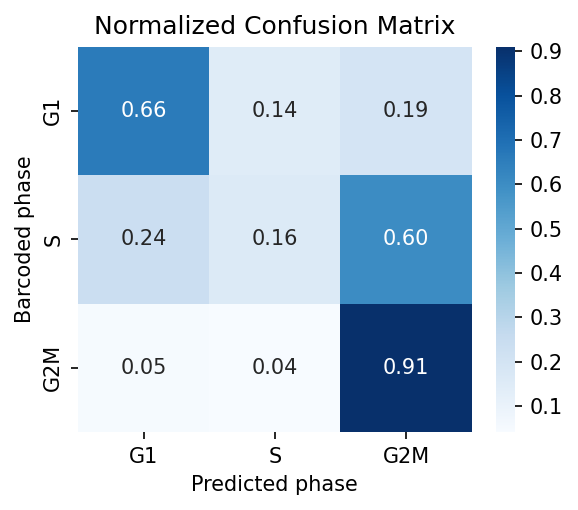

In [58]:
labels = ['G1', 'S', 'G2M']
y_true = df['assigned_condition']
y_pred = df['phase'] 

# Compute confusion matrix
cm = confusion_matrix(
    y_true, 
    y_pred,
    labels=labels
)

cdf = pd.DataFrame(cm, index=labels, columns=labels)
display(cdf)

# normalized confusion matrix
cm_norm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels,
    normalize="true"
)

cndf = pd.DataFrame(cm_norm, index=labels, columns=labels)
display(cndf)


print(classification_report(y_true, y_pred, labels=labels))

print("Balanced accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Cohen kappa:", cohen_kappa_score(y_true, y_pred, labels=labels))
print("MCC:", matthews_corrcoef(y_true, y_pred))


plt.figure(figsize=(4, 3.5), dpi=150)
sns.heatmap(
    cndf,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True
)

plt.ylabel("Barcoded phase")
plt.xlabel("Predicted phase")
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

# Check marker genes

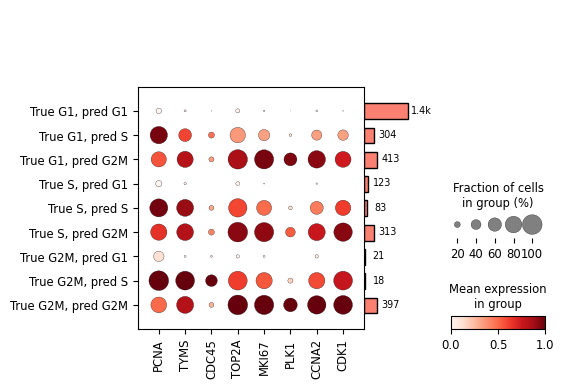

In [70]:
# check markers for TRUE/TRUE 
cdata.obs["phase_comparison"] = (
    "True " + cdata.obs["assigned_condition"].astype(str)
    + ", pred " + cdata.obs["phase"].astype(str)
)

order = [
    "True G1, pred G1",
    "True G1, pred S",
    "True G1, pred G2M",
    "True S, pred G1",
    "True S, pred S",
    "True S, pred G2M",
    "True G2M, pred G1",
    "True G2M, pred S",
    "True G2M, pred G2M",
]

cdata.obs["phase_comparison"] = pd.Categorical(
    cdata.obs["phase_comparison"],
    categories=order,
    ordered=True,
)

marker_genes = ['PCNA', 'TYMS', 'CDC45', 'TOP2A', 'MKI67', 'PLK1', 'CCNA2', 'CDK1']
marker_genes = [g for g in marker_genes if g in cdata.var_names]

plt.rcdefaults()
dp = sc.pl.dotplot(
    cdata,
    var_names=marker_genes,
    groupby='phase_comparison',
    layer='log_norm',
    standard_scale='var',
    return_fig=True,
)
dp.add_totals().show()

# Ground truth labels
Only retain cells where barcoded phase and predicted phase match

In [73]:
# groups_to_keep = [
#     "True G1, pred G1",
#     "True S, pred S",
#     "True G2M, pred G2M",
# ]

# gdata = cdata[cdata.obs['phase_comparison'].isin(groups_to_keep), :].copy()

# total_cells = gdata.shape[0]
# print(f"Total cells: {total_cells}")

# # remove genes expressed in fewer than 5% of cells
# cell_gene_thresh = total_cells * 0.05
# print(cell_gene_thresh)

# sc.pp.filter_genes(gdata, min_cells=cell_gene_thresh)

# # renormalize
# gdata.X = gdata.layers['raw_counts'].copy()
# sc.pp.normalize_total(gdata, target_sum=1e4)
# gdata.layers['norm'] = gdata.X.copy()
# sc.pp.log1p(gdata)
# gdata.layers['log_norm'] = gdata.X.copy()

# gdata

Total cells: 1883
94.15
filtered out 7535 genes that are detected in less than 94.15 cells
normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 1883 × 10682
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'doublet_score', 'predicted_doublet', 'bad_hto', 'S_score', 'G2M_score', 'phase', 'phase_comparison'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_to

In [76]:
# gdata.obs['phase'].value_counts(normalize=True)

phase
G1     0.745088
G2M    0.210834
S      0.044079
Name: proportion, dtype: float64

In [75]:
%%time
# 1. X is your normalized gene/isoform expression matrix, y is your HTO labels
X = gdata.to_df() 
y = gdata.obs['phase']

# 2. Crucial: Split by stratified strategy so train/test have equal phase distributions
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 3. Train the model
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# 4. Evaluate and extract predictive features
print(classification_report(y_test, rf.predict(X_test)))
importances = rf.feature_importances_

              precision    recall  f1-score   support

          G1       0.99      1.00      1.00       281
         G2M       0.84      1.00      0.91        79
           S       0.00      0.00      0.00        17

    accuracy                           0.95       377
   macro avg       0.61      0.67      0.64       377
weighted avg       0.92      0.95      0.93       377

CPU times: user 3.96 s, sys: 8.17 ms, total: 3.97 s
Wall time: 4 s


In [86]:
print(cdata)
display(cdata.obs['assigned_condition'].value_counts(normalize=True))

### Further filter genes, renormalize

gdata = cdata.copy()

total_cells = gdata.shape[0]
print(f"Total cells: {total_cells}")

# remove genes expressed in fewer than 5% of cells
cell_gene_thresh = total_cells * 0.05
print(cell_gene_thresh)

sc.pp.filter_genes(gdata, min_cells=cell_gene_thresh)

# renormalize
gdata.X = gdata.layers['raw_counts'].copy()
sc.pp.normalize_total(gdata, target_sum=1e4)
gdata.layers['norm'] = gdata.X.copy()
sc.pp.log1p(gdata)
gdata.layers['log_norm'] = gdata.X.copy()

gdata

AnnData object with n_obs × n_vars = 3075 × 18217
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'doublet_score', 'predicted_doublet', 'bad_hto', 'S_score', 'G2M_score', 'phase', 'phase_comparison'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_to

assigned_condition
G1     0.689431
S      0.168780
G2M    0.141789
Name: proportion, dtype: float64

Total cells: 3075
153.75
filtered out 7361 genes that are detected in less than 153.75 cells
normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 3075 × 10856
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'doublet_score', 'predicted_doublet', 'bad_hto', 'S_score', 'G2M_score', 'phase', 'phase_comparison'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'n_cells', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_to

Filtering for TRUE/TRUE cells, the model will likely just predict the features matching regev gene list
Using the 3075 high-confidence HTO cells, with class_weight='balanced' in the RF classifier, S recall/f1-score is sooo low.
Plan to downsample each condition to the lowest number of cells per class

In [88]:
%%time
# # 1. X is your normalized gene/isoform expression matrix, y is your HTO labels
# X = gdata.to_df() 
# y = gdata.obs['assigned_condition']

# # 2. Crucial: Split by stratified strategy so train/test have equal phase distributions
# X_train, X_test, y_train, y_test = train_test_split(
#     X, 
#     y, 
#     test_size=0.2, 
#     stratify=y, 
#     random_state=42,
# )

# # 3. Train the model
# rf = RandomForestClassifier(
#     n_estimators=100, 
#     class_weight='balanced',
#     random_state=42, 
#     n_jobs=-1,
# )
# rf.fit(X_train, y_train)

# # 4. Evaluate and extract predictive features
# print(classification_report(y_test, rf.predict(X_test)))
# importances = rf.feature_importances_

# 1. X is your normalized gene/isoform expression matrix, y is your HTO labels
X = gdata.to_df() 
y = gdata.obs['assigned_condition']

# 2. Crucial: Split by stratified strategy so train/test have equal phase distributions
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42,
)


# Combine training data back into a temporary DataFrame to resample together
train_df = X_train.copy()
train_df['target'] = y_train

# Separate the classes
df_g1 = train_df[train_df['target'] == 'G1']
df_s  = train_df[train_df['target'] == 'S']
df_g2m = train_df[train_df['target'] == 'G2M']

# smallest class in the training set
n_samples_target = len(df_g2m) #min(len(df_g1), len(df_s), len(df_g2m)) 

# Downsample the majority classes
df_g1_downsampled = resample(df_g1, replace=False, n_samples=n_samples_target, random_state=42)
df_s_downsampled = resample(df_s, replace=False, n_samples=n_samples_target, random_state=42)
# df_g2m_downsampled = resample(df_g2m, replace=False, n_samples=n_samples_target, random_state=42)

# Combine them back into a perfectly balanced training dataset
balanced_train_df = pd.concat([df_g1_downsampled, df_s_downsampled, df_g2m])

# Split back into X and y
X_train_balanced = balanced_train_df.drop(columns=['target'])
y_train_balanced = balanced_train_df['target']

print(f"New training set size: {X_train_balanced.shape[0]} cells ({n_samples_target} per phase)")


# 3. Train the model
rf = RandomForestClassifier(
    n_estimators=100, 
    random_state=42, 
    n_jobs=-1,
)
rf.fit(X_train_balanced, y_train_balanced)

print(classification_report(y_test, rf.predict(X_test)))

New training set size: 1047 cells (349 per phase)
              precision    recall  f1-score   support

          G1       0.90      0.72      0.80       424
         G2M       0.47      0.83      0.60        87
           S       0.39      0.47      0.43       104

    accuracy                           0.69       615
   macro avg       0.59      0.67      0.61       615
weighted avg       0.75      0.69      0.71       615

CPU times: user 3.58 s, sys: 288 ms, total: 3.87 s
Wall time: 3.91 s


In [98]:
feature_names = X.columns
feat_importances = pd.Series(rf.feature_importances_, index=feature_names)
top_30_genes = feat_importances.sort_values(ascending=False).head(30)

# 2. Map to mean expression per phase across your entire dataset
X_with_phase = X[top_30_genes.index].copy()
X_with_phase['assigned_condition'] = y
mean_expr_per_phase = X_with_phase.groupby('assigned_condition').mean().T
mean_expr_zscore = mean_expr_per_phase.apply(lambda x: (x - x.mean()) / x.std(), axis=1)

# print("--- Top 10 Most Predictive Genes/Isoforms Across Phases ---")
# display(mean_expr_per_phase.head(30))

print("--- Z-score Normalized Expression (Relative Spikes) ---")
display(mean_expr_zscore.head(30))

--- Z-score Normalized Expression (Relative Spikes) ---


/tmp/ipykernel_3447028/1919102696.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_expr_per_phase = X_with_phase.groupby('assigned_condition').mean().T


assigned_condition,G1,G2M,S
gene_name,,,
UBE2C,-1.018831,0.980040,0.038790
HMMR,-1.004648,0.995286,0.009362
PTTG1,-1.016104,0.983077,0.033027
DLGAP5,-0.934248,1.054819,-0.120571
H2AZ1,-1.087373,0.880160,0.207213
CDKN3,-0.917111,1.066158,-0.149047
HMGB2,-1.060108,0.926447,0.133661
TOP2A,-1.062962,0.922101,0.140861
CKS2,-0.976535,1.021920,-0.045385


In [99]:
%%time
# 1. Create a binary target for just S phase in the test set
y_test_s = (y_test == 'S').astype(int)

# 2. Define a custom scorer that measures the F1-score of the S-phase class specifically
def s_phase_f1_scorer(estimator, X_subset, y_subset):
    preds = estimator.predict(X_subset)
    preds_binary = (preds == 'S').astype(int)
    return f1_score(y_subset, preds_binary, zero_division=0)

# 3. Calculate permutation importance on your BALANCED model using the S-phase scorer
print("Calculating S-phase specific feature importances (this may take a minute)...")
result_s = permutation_importance(
    rf, X_test, y_test_s, scoring=s_phase_f1_scorer, n_repeats=5, random_state=42, n_jobs=-1
)

# 4. Map back to gene names and sort
s_importances = pd.Series(result_s.importances_mean, index=X.columns)
top_s_genes = s_importances.sort_values(ascending=False).head(20)

print("\n--- Top 20 Features Crucial for Predicting S-Phase ---")
print(top_s_genes)

Calculating S-phase specific feature importances (this may take a minute)...

--- Top 20 Features Crucial for Predicting S-Phase ---
gene_name
VEGFA     0.013614
CKS2      0.011134
CEP55     0.010705
DLGAP5    0.010672
CENPE     0.010652
ERO1A     0.009677
AURKA     0.009341
TUBA1C    0.009298
TRIM59    0.009169
USP1      0.009166
MYL6      0.008730
CFL1      0.008656
PLD3      0.008366
DBI       0.008363
GTSE1     0.008220
COL1A2    0.007998
PKD1      0.007992
FTH1      0.007627
LSM5      0.007545
NT5E      0.007360
dtype: float64
CPU times: user 47min 49s, sys: 8.45 s, total: 47min 57s
Wall time: 48min 48s


In [81]:
# feature_names = X.columns
# feat_importances = pd.Series(rf.feature_importances_, index=feature_names)

# # Sort them to get the top 30 heaviest hitters
# top_genes = feat_importances.sort_values(ascending=False).head(30)

# print("--- Top 30 Most Predictive Genes/Isoforms ---")
# print(top_genes)

--- Top 30 Most Predictive Genes/Isoforms ---
gene_name
HMMR         0.006709
UBE2C        0.006213
PTTG1        0.005755
H2AZ1        0.005729
DLGAP5       0.005522
HMGB2        0.005432
CDKN3        0.005175
TOP2A        0.005102
CDCA8        0.004375
CKS2         0.004283
PRC1         0.004017
CCNB1        0.003895
DEK          0.003873
NUSAP1       0.003728
ANLN         0.003577
STMN1        0.003382
TMPO         0.003016
FBXO5        0.002915
SMC4         0.002863
RAD51AP1     0.002637
TK1          0.002618
GTSE1        0.002497
ARHGAP11A    0.002448
CENPE        0.002403
RRM2         0.002326
MT2A         0.002290
HMGB1        0.002281
CDC20        0.002219
KPNA2        0.002216
CEP55        0.002187
dtype: float64


In [82]:
# 1. Get the names of your top 30 genes
top_30_gene_names = top_genes.index

# 2. Add the phase labels back to your normalized expression dataframe
X_with_phase = X[top_30_gene_names].copy()
X_with_phase['assigned_condition'] = y

# 3. Calculate the mean log-normalized expression per phase
mean_expr_per_phase = X_with_phase.groupby('assigned_condition').mean().T

print("--- Mean Expression of Top Genes per Phase ---")
print(mean_expr_per_phase.head(10))

--- Mean Expression of Top Genes per Phase ---
assigned_condition        G1       G2M         S
gene_name                                       
HMMR                0.256567  1.062307  0.665095
UBE2C               0.391647  1.879747  1.179014
PTTG1               0.583030  1.889040  1.268398
H2AZ1               1.533080  2.648013  2.266677
DLGAP5              0.279714  1.204226  0.657908
HMGB2               0.756010  2.133962  1.584054
CDKN3               0.233532  0.959101  0.514524
TOP2A               0.608525  2.358803  1.669965
CDCA8               0.241607  0.960600  0.521951
CKS2                0.911994  2.095046  1.463219


/tmp/ipykernel_3447028/3885394541.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_expr_per_phase = X_with_phase.groupby('assigned_condition').mean().T


In [84]:
phases = ['G1', 'S', 'G2M'] # Replace with your exact HTO string labels if different
phase_specific_importances = {}

for phase in phases:
    # Create a binary target for this specific phase
    y_test_binary = (y_test == phase).astype(int)
    
    # Custom scorer that looks at the F1-score for just this phase
    def phase_f1_scorer(estimator, X_subset, y_subset):
        preds = estimator.predict(X_subset)
        preds_binary = (preds == phase).astype(int)
        # Calculate F1 for the positive binary class
        from sklearn.metrics import f1_score
        return f1_score(y_subset, preds_binary)

    # Compute permutation importance using our phase-specific scorer
    result = permutation_importance(
        rf, X_test, y_test_binary, scoring=phase_f1_scorer, n_repeats=5, random_state=42, n_jobs=-1
    )
    
    # Store the mean importance drop
    phase_specific_importances[phase] = pd.Series(result.importances_mean, index=X.columns)

# Combine into a single DataFrame
df_phase_importance = pd.DataFrame(phase_specific_importances)

# View the top 10 genes driving S-phase specifically
print("--- Top 10 S-Phase Specific Drivers ---")
print(df_phase_importance.sort_values(by='S', ascending=False)['S'].head(10))


KeyboardInterrupt



In [6]:
adata.obs.head()

,MYOD-fb_counts,PRRX1-fb_counts,PRRX1_MYOD-fb_counts,assigned_condition,total_fb_counts,condition_counts_rate,G1-fb_counts,G2M-fb_counts,S-fb_counts,dataset,total_reads,total_genes
AAACCAAAGGGTAGCA_control,NaN,NaN,NaN,G2M,2.0,1.00,0.0,2.0,0.0,Control,20406.0,4556
AAACCAAAGTAAGGGT_control,NaN,NaN,NaN,G1,2.0,1.00,2.0,0.0,0.0,Control,10160.0,2799
AAACCATTCAGGTAGG_control,NaN,NaN,NaN,G1,2.0,1.00,2.0,0.0,0.0,Control,20044.0,4540
AAACCATTCCAGCCCT_control,NaN,NaN,NaN,S,4.0,1.00,0.0,0.0,4.0,Control,13258.0,3055
AAACCATTCGTGACCG_control,NaN,NaN,NaN,G1,4.0,0.75,3.0,0.0,1.0,Control,11546.0,3222


In [7]:
adata.obs['condition_counts_rate'].describe()

count    8875.000000
mean        0.763392
std         0.201473
min         0.333333
25%         0.600000
50%         0.750000
75%         1.000000
max         1.000000
Name: condition_counts_rate, dtype: float64

In [8]:
adata.obs.sort_values(by='condition_counts_rate').head()

,MYOD-fb_counts,PRRX1-fb_counts,PRRX1_MYOD-fb_counts,assigned_condition,total_fb_counts,condition_counts_rate,G1-fb_counts,G2M-fb_counts,S-fb_counts,dataset,total_reads,total_genes
TGTGAACCAATAGCCG_control,NaN,NaN,NaN,G1,3.0,0.333333,1.0,1.0,1.0,Control,9300.0,2780
TCAGCAATCCCTCGTA_control,NaN,NaN,NaN,G1,3.0,0.333333,1.0,1.0,1.0,Control,27.0,27
CAAGGTAGTTGAGTCT_control,NaN,NaN,NaN,G1,3.0,0.333333,1.0,1.0,1.0,Control,4952.0,2023
CAAGGGGCAAATCGGT_control,NaN,NaN,NaN,G1,3.0,0.333333,1.0,1.0,1.0,Control,16854.0,4138
AACAGGTAGAAGGTCG_control,NaN,NaN,NaN,G1,3.0,0.333333,1.0,1.0,1.0,Control,41.0,39


In [ ]:
# exclude cells with even # of reads per feature barcode (e.g., condition_counts_rate = 0.33)

In [4]:
adata.obs['phase'].value_counts()

phase
G1     5733
S      1689
G2M    1453
Name: count, dtype: int64